In [1]:
# Financial Transactions Data Analysis and Automation

In [2]:
#Import Libraries 
import pandas as pd
import numpy as np
import datetime as datetime

In [3]:
# 2. Load the Data

In [4]:
df = pd.read_csv("Downloads\Financial_Transactions_Dataset.csv")

In [5]:
## 3. Inspect the Data

In [6]:
df.head()

,Transaction_ID,Date,Department,Region,Transaction_Type,Payment_Method,Account_Type,Description,Amount,Annual_Budget
0,FIN20556,2025-11-15,Sales,Port Harcourt,Income,Cash,Current Account,Client Payment,1184002.0,9000000
1,FIN21745,2025-05-03,Operations,Kano,Income,Bank Transfer,Current Account,Advertising,833494.0,8500000
2,FIN20298,2025-08-04,IT,Ibadan,Income,Mobile Money,Business Account,Client Payment,1786032.0,7200000
3,FIN20734,2025-05-17,IT,Lagos,Expense,Cash,Savings Account,Advertising,428376.0,7200000
4,FIN20911,2025-09-24,Human Resources,Ibadan,Expense,Direct Debit,Savings Account,Service Fee,201871.0,5000000


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction_ID    1825 non-null   str    
 1   Date              1825 non-null   str    
 2   Department        1825 non-null   str    
 3   Region            1800 non-null   str    
 4   Transaction_Type  1825 non-null   str    
 5   Payment_Method    1825 non-null   str    
 6   Account_Type      1825 non-null   str    
 7   Description       1807 non-null   str    
 8   Amount            1805 non-null   float64
 9   Annual_Budget     1825 non-null   int64  
dtypes: float64(1), int64(1), str(8)
memory usage: 276.3 KB


In [8]:
df.shape

(1825, 10)

In [9]:
# 4. Clean the Data

In [10]:
df.isnull().sum()

Transaction_ID       0
Date                 0
Department           0
Region              25
Transaction_Type     0
Payment_Method       0
Account_Type         0
Description         18
Amount              20
Annual_Budget        0
dtype: int64

In [11]:
# 4.1 Handle Missing Values

In [12]:
df["Region"] = df["Region"].fillna("Unknown")

In [13]:
df["Description"] = df["Description"].fillna("Unknown")

In [14]:
df["Amount"] = df["Amount"].fillna(df["Amount"].median())

In [15]:
# 4.2 Remove Duplicates

In [16]:
df = df.drop_duplicates()

In [17]:
df.isnull().sum()

Transaction_ID      0
Date                0
Department          0
Region              0
Transaction_Type    0
Payment_Method      0
Account_Type        0
Description         0
Amount              0
Annual_Budget       0
dtype: int64

In [18]:
#5. Transform the Data

In [19]:
#5.1 Create Month Column

In [20]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

In [21]:
df["Date"].dtype

dtype('<M8[us]')

In [22]:
df["Month"] = df["Date"].dt.to_period("M")

In [23]:
df.head()

,Transaction_ID,Date,Department,Region,Transaction_Type,Payment_Method,Account_Type,Description,Amount,Annual_Budget,Month
0,FIN20556,2025-11-15,Sales,Port Harcourt,Income,Cash,Current Account,Client Payment,1184002.0,9000000,2025-11
1,FIN21745,2025-05-03,Operations,Kano,Income,Bank Transfer,Current Account,Advertising,833494.0,8500000,2025-05
2,FIN20298,2025-08-04,IT,Ibadan,Income,Mobile Money,Business Account,Client Payment,1786032.0,7200000,2025-08
3,FIN20734,2025-05-17,IT,Lagos,Expense,Cash,Savings Account,Advertising,428376.0,7200000,2025-05
4,FIN20911,2025-09-24,Human Resources,Ibadan,Expense,Direct Debit,Savings Account,Service Fee,201871.0,5000000,2025-09


In [24]:
# 6. Analyse the Data

In [25]:
# 6.1 Total Transactions

In [26]:
Total_transactions = df["Transaction_ID"].count()

print(Total_transactions)

1800


In [27]:
#5.	Aggregate

In [28]:
df["Amount"].mean()

np.float64(639091.6011111111)

In [29]:
df["Amount"].max()

np.float64(1799014.0)

In [30]:
df["Amount"].min()

np.float64(21539.0)

In [31]:
df["Amount"].median()

np.float64(504528.0)

In [32]:
# 7. Monthly Financial Report
# 7.1 Monthly Income and Expenses

In [33]:
df["Transaction_Type"].value_counts()

Transaction_Type
Income     930
Expense    870
Name: count, dtype: int64

In [34]:
Monthly_Income = (
    df[df["Transaction_Type"] == "Income"]
    .groupby("Month")["Amount"]
    .sum()
    .reset_index()
)

print(Monthly_Income)

      Month      Amount
0   2025-01  72118202.0
1   2025-02  70357945.0
2   2025-03  96634778.0
3   2025-04  74179658.0
4   2025-05  66718405.0
5   2025-06  60204675.0
6   2025-07  75990871.0
7   2025-08  71052379.0
8   2025-09  64926239.0
9   2025-10  72093872.0
10  2025-11  67987258.0
11  2025-12  59209129.0


In [35]:
Monthly_Expenses= (
    df[df["Transaction_Type"] == "Expense"]
    .groupby("Month")["Amount"]
    .sum()
    .reset_index()
)

print(Monthly_Expenses)

      Month      Amount
0   2025-01  27445428.0
1   2025-02  19723373.0
2   2025-03  24235590.0
3   2025-04  27310979.0
4   2025-05  30138743.0
5   2025-06  25132497.0
6   2025-07  28372544.0
7   2025-08  22703883.0
8   2025-09  23846026.0
9   2025-10  18044338.0
10  2025-11  24573140.0
11  2025-12  27364930.0


In [36]:
Monthly_Financial_Report = pd.merge(
    Monthly_Income,
    Monthly_Expenses,
    on="Month",
    how="outer",
    suffixes=("_Income", "_Expense")
)

print(Monthly_Financial_Report)

      Month  Amount_Income  Amount_Expense
0   2025-01     72118202.0      27445428.0
1   2025-02     70357945.0      19723373.0
2   2025-03     96634778.0      24235590.0
3   2025-04     74179658.0      27310979.0
4   2025-05     66718405.0      30138743.0
5   2025-06     60204675.0      25132497.0
6   2025-07     75990871.0      28372544.0
7   2025-08     71052379.0      22703883.0
8   2025-09     64926239.0      23846026.0
9   2025-10     72093872.0      18044338.0
10  2025-11     67987258.0      24573140.0
11  2025-12     59209129.0      27364930.0


In [37]:
## 8. Financial Summary

In [38]:
total_income = df.loc[df["Transaction_Type"] == "Income", "Amount"].sum()

total_expenses = df.loc[df["Transaction_Type"] == "Expense", "Amount"].sum()

net_cash_flow = total_income - total_expenses

average_transaction = df["Amount"].mean()

max_transaction = df["Amount"].max()

min_transaction = df["Amount"].min()

median_transaction = df["Amount"].median()

Financial_Summary = pd.DataFrame({
    "Metrics": [
        "Total_Income",
        "Total_Expenses",
        "Net_Cash_Flow",
        "Average_Transaction",
        "Maximum_Transaction",
        "Minimum_Transaction",
        "Median_Transaction"
    ],
    "Values": [
        total_income,
        total_expenses,
        net_cash_flow,
        average_transaction,
        max_transaction,
        min_transaction,
        median_transaction
    ]
})

print(Financial_Summary)

               Metrics        Values
0         Total_Income  8.514734e+08
1       Total_Expenses  2.988915e+08
2        Net_Cash_Flow  5.525819e+08
3  Average_Transaction  6.390916e+05
4  Maximum_Transaction  1.799014e+06
5  Minimum_Transaction  2.153900e+04
6   Median_Transaction  5.045280e+05


In [39]:
#Export Dataset

In [40]:
df.to_csv("Clean_Financial_Data_Analysis.csv", index=False)

In [41]:
Monthly_Financial_Report.to_csv("Monthly_Financial_Report.csv", index=False)

In [42]:
Financial_Summary.to_csv("Financial_Summary.csv", index=False)

In [43]:
# Build the complete Automation Pipeline

import pandas as pd
import numpy as np
import datetime as datetime

# 1. Load
df = pd.read_csv("Downloads\Financial_Transactions_Dataset.csv")

# 2. Clean
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Region"] = df["Region"].fillna("Unknown")
df["Description"] = df["Description"].fillna("Unknown")
df["Amount"] = df["Amount"].fillna(df["Amount"].median())
df = df.drop_duplicates()

# 3. Transform
df["Month"] = df["Date"].dt.to_period("M").astype(str)

# 4. Analyse Total Transactions
total_transactions = df["Transaction_ID"].count()

# 5. Create Monthly Report
monthly_report = df.groupby(
    ["Month", "Transaction_Type"]
)["Amount"].sum().reset_index()

# 6. Create Financial Summary
total_income = df.loc[
    df["Transaction_Type"] == "Income", "Amount"
].sum()

total_expenses = df.loc[
    df["Transaction_Type"] == "Expense", "Amount"
].sum()

net_cash_flow = total_income - total_expenses

average_transaction = df["Amount"].mean()
maximum_transaction = df["Amount"].max()
minimum_transaction = df["Amount"].min()
median_transaction = df["Amount"].median()

Financial_Summary = pd.DataFrame({
    "Metrics": [
        "Total_Transactions",
        "Total_Income",
        "Total_Expenses",
        "Net_Cash_Flow",
        "Average_Transaction",
        "Maximum_Transaction",
        "Minimum_Transaction",
        "Median_Transaction"
    ],
    "Values": [
        total_transactions,
        total_income,
        total_expenses,
        net_cash_flow,
        average_transaction,
        maximum_transaction,
        minimum_transaction,
        median_transaction
    ]
})

# 7. Export
df.to_csv(
    "Clean_Financial_Data_Analysis.csv",
    index=False
)

monthly_report.to_csv(
    "monthly_report.csv",
    index=False
)

Financial_Summary.to_csv(
    "Financial_Summary.csv",
    index=False
)

print("Financial reporting automation pipeline completed.")

Financial reporting automation pipeline completed.


In [44]:
# Build pipeline automation for Visual or chart

In [45]:
#Import Libraries 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
#Load Data
df = pd.read_csv("Downloads\Financial_Transactions_Dataset.csv")

In [47]:
# Prepare Monthly Data
Monthly_Financial_Summary = ("Monthly_Financial_Report.csv")

In [48]:
monthly_report.columns

Index(['Month', 'Transaction_Type', 'Amount'], dtype='str')

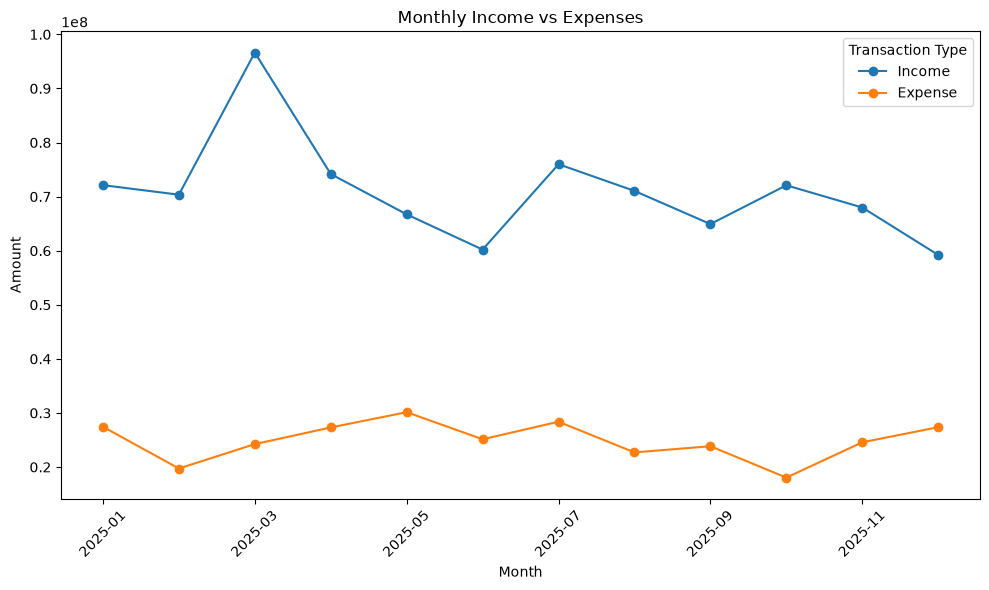

In [49]:
# Create Monthly Income vs Expenses Visual

import matplotlib.pyplot as plt

# Pivot the monthly report
monthly_cash_flow = monthly_report.pivot_table(
    index="Month",
    columns="Transaction_Type",
    values="Amount",
    aggfunc="sum",
    fill_value=0
).reset_index()

# Make sure Income and Expense columns exist
if "Income" not in monthly_cash_flow.columns:
    monthly_cash_flow["Income"] = 0

if "Expense" not in monthly_cash_flow.columns:
    monthly_cash_flow["Expense"] = 0

# Plot Monthly Income vs Expenses
monthly_cash_flow.plot(
    x="Month",
    y=["Income", "Expense"],
    kind="line",
    marker="o",
    figsize=(10, 6)
)

plt.title("Monthly Income vs Expenses")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.legend(title="Transaction Type")
plt.tight_layout()
plt.show()

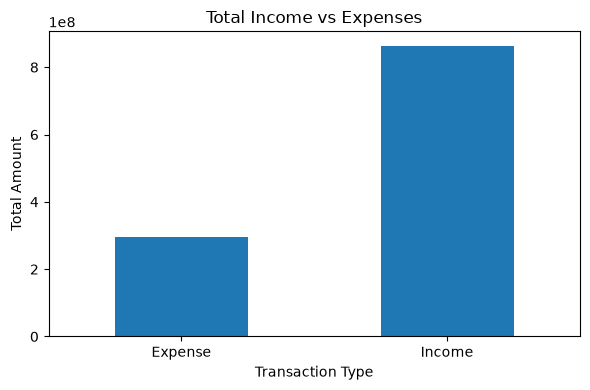

In [50]:
# 4. Create Income vs Expenses Bar Chart

income_expense = df.groupby(
    "Transaction_Type"
)["Amount"].sum()

income_expense.plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Total Income vs Expenses")
plt.xlabel("Transaction Type")
plt.ylabel("Total Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

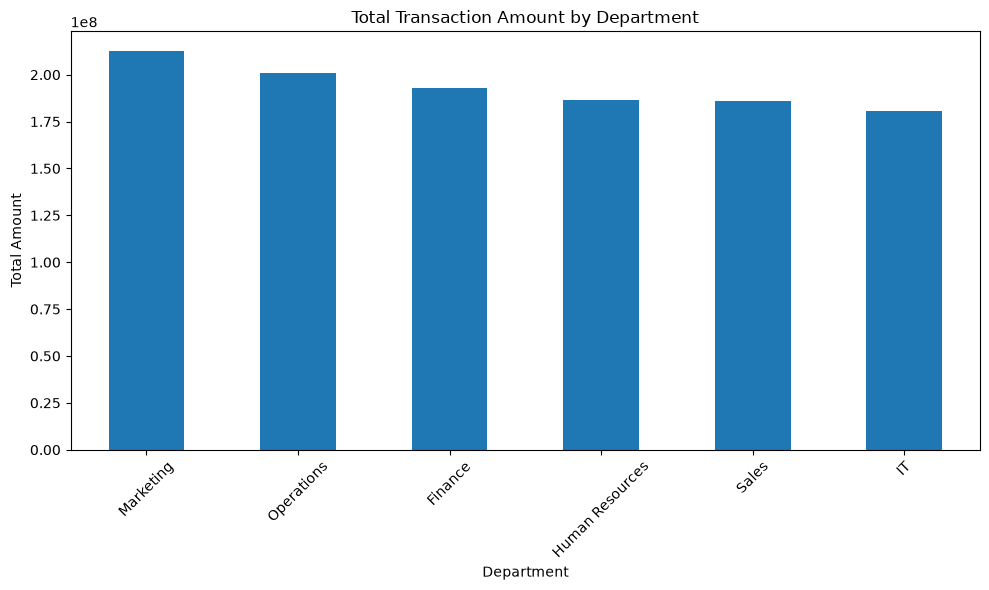

In [51]:
# 4. Create Total Amount by Department Chart

department_amount = df.groupby(
    "Department"
)["Amount"].sum().sort_values(ascending=False)

department_amount.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Total Transaction Amount by Department")
plt.xlabel("Department")
plt.ylabel("Total Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

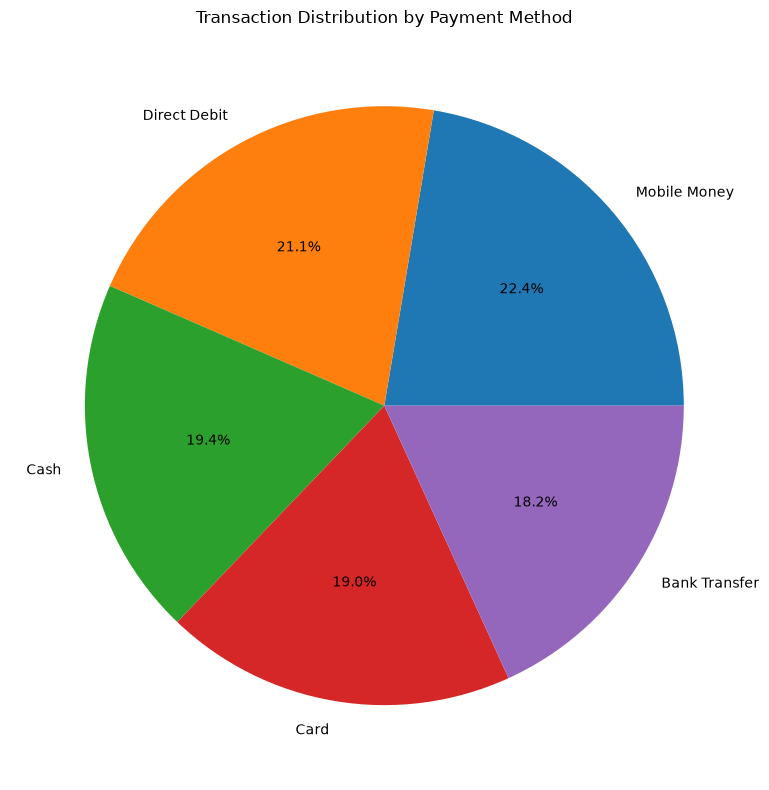

In [52]:
# 5. Create Transaction Distribution by Payment Method

payment_method = df["Payment_Method"].value_counts()

payment_method.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(8, 8)
)

plt.title("Transaction Distribution by Payment Method")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [53]:
!pip install plotly

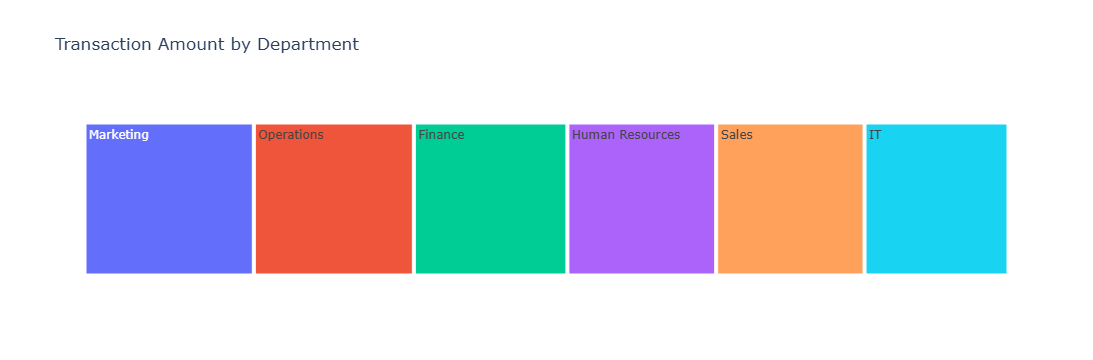

In [54]:
# 6. Create Department Treemap

import plotly.express as px

department_amount = df.groupby(
    "Department"
)["Amount"].sum().sort_values(ascending=False).reset_index()

fig = px.treemap(
    department_amount,
    path=["Department"],
    values="Amount",
    title="Transaction Amount by Department"
)

fig.show()

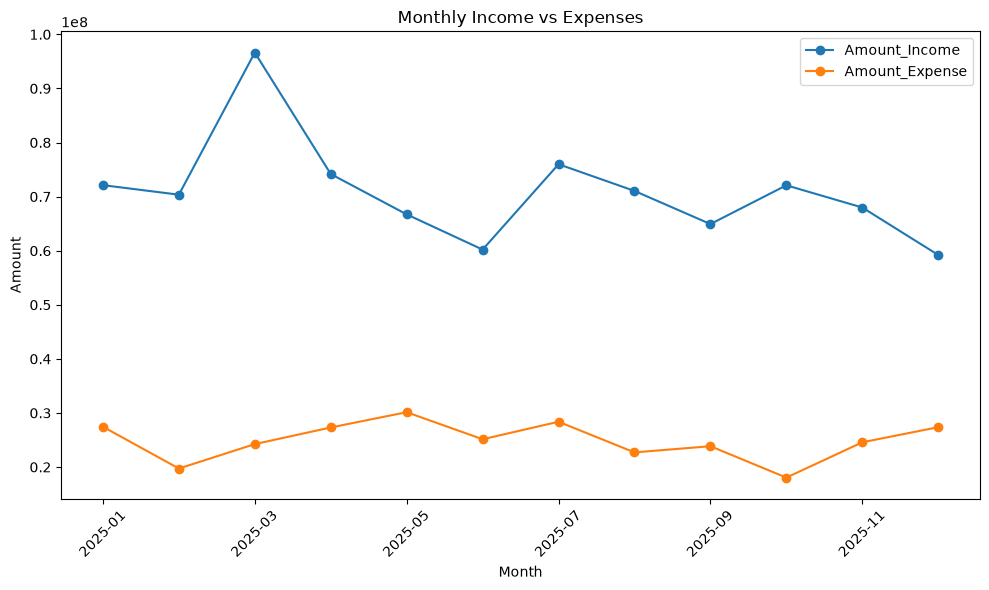

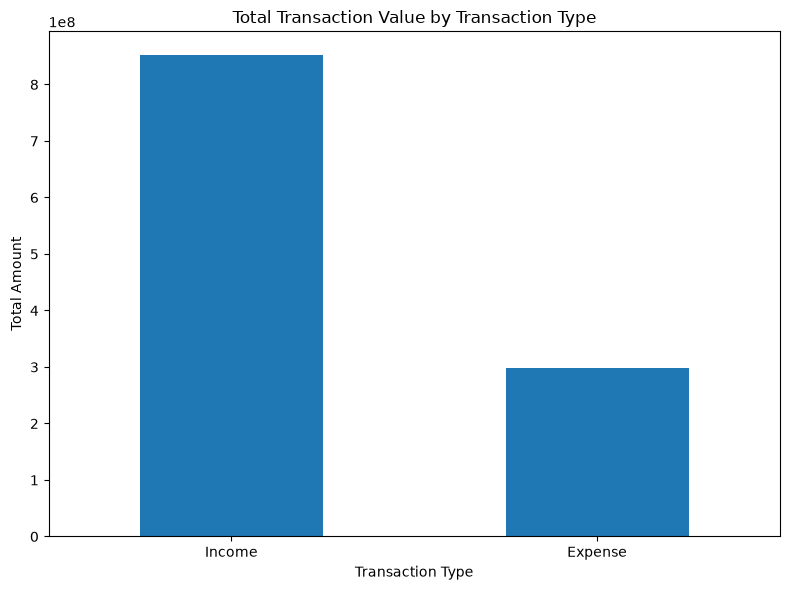

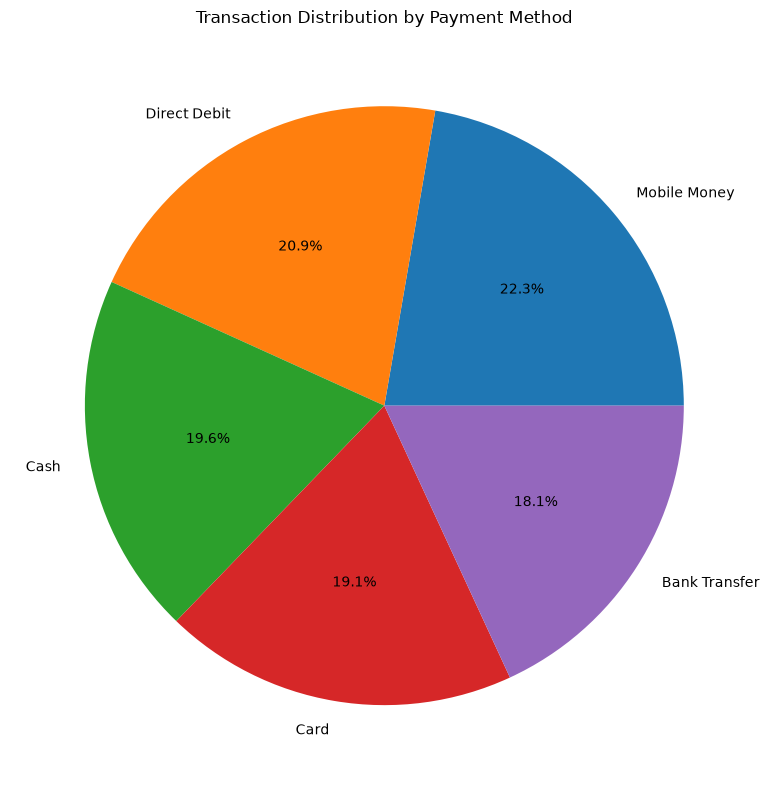

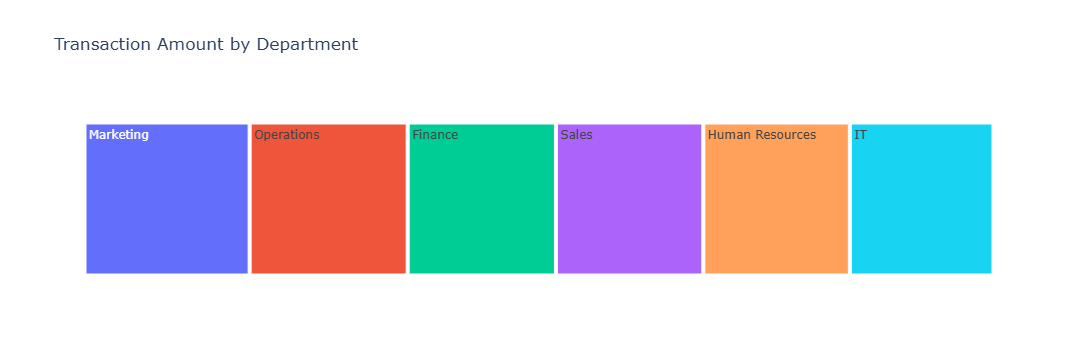

Visualisation automation pipeline completed.


In [55]:
# Build the Complete Visualisation Automation Pipeline

import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

# 1. Load Clean Data
df = pd.read_csv("Clean_Financial_Data.csv")

# 2. Load Monthly Report
monthly_report = pd.read_csv("Monthly_Financial_Report.csv")


# 3. Monthly Income vs Expenses
monthly_report.plot(
    x="Month",
    y=["Amount_Income", "Amount_Expense"],
    kind="line",
    marker="o",
    figsize=(10, 6)
)

plt.title("Monthly Income vs Expenses")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 4. Total Transaction Value by Transaction Type
transaction_type_amount = df.groupby(
    "Transaction_Type"
)["Amount"].sum().sort_values(ascending=False)

transaction_type_amount.plot(
    kind="bar",
    figsize=(8, 6)
)

plt.title("Total Transaction Value by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Total Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# 5. Transaction Distribution by Payment Method
payment_method = df["Payment_Method"].value_counts()

payment_method.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(8, 8)
)

plt.title("Transaction Distribution by Payment Method")
plt.ylabel("")
plt.tight_layout()
plt.show()


# 6. Department Transaction Treemap
department_amount = df.groupby(
    "Department"
)["Amount"].sum().sort_values(
    ascending=False
).reset_index()

fig = px.treemap(
    department_amount,
    path=["Department"],
    values="Amount",
    title="Transaction Amount by Department"
)

fig.show()


print("Visualisation automation pipeline completed.")

In [56]:
monthly_report = pd.read_csv("Monthly_Financial_Report.csv")

print(monthly_report.columns.tolist())
print(monthly_report.head())

['Month', 'Amount_Income', 'Amount_Expense']
     Month  Amount_Income  Amount_Expense
0  2025-01     72118202.0      27445428.0
1  2025-02     70357945.0      19723373.0
2  2025-03     96634778.0      24235590.0
3  2025-04     74179658.0      27310979.0
4  2025-05     66718405.0      30138743.0


In [57]:
import pandas as pd

# 1. Load the monthly report
monthly_report = pd.read_csv("Monthly_Financial_Report.csv")

# 2. Create Monthly Cash Flow table
monthly_cash_flow = monthly_report.copy()

# 3. Calculate Net Cash Flow
monthly_cash_flow["Net_Cash_Flow"] = (
    monthly_cash_flow["Amount_Income"] -
    monthly_cash_flow["Amount_Expense"]
)

# 4. Calculate Cash Flow Margin
monthly_cash_flow["Cash_Flow_Margin_%"] = (
    monthly_cash_flow["Net_Cash_Flow"] /
    monthly_cash_flow["Amount_Income"]
) * 100

# 5. View Monthly Changes
monthly_cash_flow[
    [
        "Month",
        "Amount_Income",
        "Amount_Expense",
        "Net_Cash_Flow",
        "Cash_Flow_Margin_%"
    ]
]

,Month,Amount_Income,Amount_Expense,Net_Cash_Flow,Cash_Flow_Margin_%
0,2025-01,72118202.0,27445428.0,44672774.0,61.943827
1,2025-02,70357945.0,19723373.0,50634572.0,71.967099
2,2025-03,96634778.0,24235590.0,72399188.0,74.920427
3,2025-04,74179658.0,27310979.0,46868679.0,63.182657
4,2025-05,66718405.0,30138743.0,36579662.0,54.826943
5,2025-06,60204675.0,25132497.0,35072178.0,58.254908
6,2025-07,75990871.0,28372544.0,47618327.0,62.663220
7,2025-08,71052379.0,22703883.0,48348496.0,68.046273
8,2025-09,64926239.0,23846026.0,41080213.0,63.272128
9,2025-10,72093872.0,18044338.0,54049534.0,74.971052


In [58]:
# Calculate Monthly Net Cash Flow

monthly_cash_flow = monthly_report.copy()

monthly_cash_flow["Net_Cash_Flow"] = (
    monthly_cash_flow["Amount_Income"] -
    monthly_cash_flow["Amount_Expense"]
)

# Calculate Cash Flow Margin
monthly_cash_flow["Cash_Flow_Margin_%"] = (
    monthly_cash_flow["Net_Cash_Flow"] /
    monthly_cash_flow["Amount_Income"]
) * 100

# View Monthly Changes
monthly_cash_flow[
    [
        "Month",
        "Amount_Income",
        "Amount_Expense",
        "Net_Cash_Flow",
        "Cash_Flow_Margin_%"
    ]
]

,Month,Amount_Income,Amount_Expense,Net_Cash_Flow,Cash_Flow_Margin_%
0,2025-01,72118202.0,27445428.0,44672774.0,61.943827
1,2025-02,70357945.0,19723373.0,50634572.0,71.967099
2,2025-03,96634778.0,24235590.0,72399188.0,74.920427
3,2025-04,74179658.0,27310979.0,46868679.0,63.182657
4,2025-05,66718405.0,30138743.0,36579662.0,54.826943
5,2025-06,60204675.0,25132497.0,35072178.0,58.254908
6,2025-07,75990871.0,28372544.0,47618327.0,62.663220
7,2025-08,71052379.0,22703883.0,48348496.0,68.046273
8,2025-09,64926239.0,23846026.0,41080213.0,63.272128
9,2025-10,72093872.0,18044338.0,54049534.0,74.971052


In [59]:
# Month-over-Month Income Change

monthly_cash_flow["Income_MoM_%"] = (
    monthly_cash_flow["Amount_Income"].pct_change()
) * 100


# Month-over-Month Expense Change

monthly_cash_flow["Expense_MoM_%"] = (
    monthly_cash_flow["Amount_Expense"].pct_change()
) * 100


# View Monthly Changes

monthly_cash_flow[
    [
        "Month",
        "Amount_Income",
        "Amount_Expense",
        "Net_Cash_Flow",
        "Income_MoM_%",
        "Expense_MoM_%"
    ]
]

,Month,Amount_Income,Amount_Expense,Net_Cash_Flow,Income_MoM_%,Expense_MoM_%
0,2025-01,72118202.0,27445428.0,44672774.0,NaN,NaN
1,2025-02,70357945.0,19723373.0,50634572.0,-2.440794,-28.136034
2,2025-03,96634778.0,24235590.0,72399188.0,37.347357,22.877512
3,2025-04,74179658.0,27310979.0,46868679.0,-23.237100,12.689557
4,2025-05,66718405.0,30138743.0,36579662.0,-10.058355,10.353946
5,2025-06,60204675.0,25132497.0,35072178.0,-9.763018,-16.610666
6,2025-07,75990871.0,28372544.0,47618327.0,26.220881,12.891863
7,2025-08,71052379.0,22703883.0,48348496.0,-6.498796,-19.979389
8,2025-09,64926239.0,23846026.0,41080213.0,-8.622005,5.030606
9,2025-10,72093872.0,18044338.0,54049534.0,11.039655,-24.329790


In [60]:
# Highest Income Month

highest_income = monthly_cash_flow.loc[
    monthly_cash_flow["Amount_Income"].idxmax()
]

print("Highest Income Month:")
print(highest_income)


# Lowest Income Month

lowest_income = monthly_cash_flow.loc[
    monthly_cash_flow["Amount_Income"].idxmin()
]

print("\nLowest Income Month:")
print(lowest_income)


# Highest Expense Month

highest_expense = monthly_cash_flow.loc[
    monthly_cash_flow["Amount_Expense"].idxmax()
]

print("\nHighest Expense Month:")
print(highest_expense)


# Lowest Expense Month

lowest_expense = monthly_cash_flow.loc[
    monthly_cash_flow["Amount_Expense"].idxmin()
]

print("\nLowest Expense Month:")
print(lowest_expense)

Highest Income Month:
Month                    2025-03
Amount_Income         96634778.0
Amount_Expense        24235590.0
Net_Cash_Flow         72399188.0
Cash_Flow_Margin_%     74.920427
Income_MoM_%           37.347357
Expense_MoM_%          22.877512
Name: 2, dtype: object

Lowest Income Month:
Month                    2025-12
Amount_Income         59209129.0
Amount_Expense        27364930.0
Net_Cash_Flow         31844199.0
Cash_Flow_Margin_%     53.782583
Income_MoM_%          -12.911433
Expense_MoM_%          11.361145
Name: 11, dtype: object

Highest Expense Month:
Month                    2025-05
Amount_Income         66718405.0
Amount_Expense        30138743.0
Net_Cash_Flow         36579662.0
Cash_Flow_Margin_%     54.826943
Income_MoM_%          -10.058355
Expense_MoM_%          10.353946
Name: 4, dtype: object

Lowest Expense Month:
Month                    2025-10
Amount_Income         72093872.0
Amount_Expense        18044338.0
Net_Cash_Flow         54049534.0
Cash_Flow_Marg

In [61]:
# 1. Transaction Count

transaction_count = (
    df["Transaction_Type"]
    .value_counts()
    .reset_index()
)

transaction_count.columns = [
    "Transaction_Type",
    "Transaction_Count"
]

# 2. Transaction Share

transaction_count["Transaction_Share_%"] = (
    transaction_count["Transaction_Count"] /
    transaction_count["Transaction_Count"].sum()
) * 100

print(transaction_count)


# 3. Total Financial Value

transaction_value = (
    df.groupby("Transaction_Type")["Amount"]
    .sum()
    .reset_index()
)

# 4. Financial Value Share

transaction_value["Value_Share_%"] = (
    transaction_value["Amount"] /
    transaction_value["Amount"].sum()
) * 100

# 5. Average Transaction Value

average_value = (
    df.groupby("Transaction_Type")["Amount"]
    .mean()
    .reset_index()
)

average_value.columns = [
    "Transaction_Type",
    "Average_Transaction_Value"
]

# 6. Combine Everything

transaction_analysis = transaction_count.merge(
    transaction_value,
    on="Transaction_Type"
).merge(
    average_value,
    on="Transaction_Type"
)

transaction_analysis

  Transaction_Type  Transaction_Count  Transaction_Share_%
0           Income                930            51.666667
1          Expense                870            48.333333


,Transaction_Type,Transaction_Count,Transaction_Share_%,Amount,Value_Share_%,Average_Transaction_Value
0,Income,930,51.666667,851473411.0,74.017681,915562.807527
1,Expense,870,48.333333,298891471.0,25.982319,343553.414943


In [62]:
# 1. Payment Method Transaction Count

payment_count = (
    df["Payment_Method"]
    .value_counts()
    .reset_index()
)

payment_count.columns = [
    "Payment_Method",
    "Transaction_Count"
]

# 2. Transaction Share

payment_count["Transaction_Share_%"] = (
    payment_count["Transaction_Count"] /
    payment_count["Transaction_Count"].sum()
) * 100

# 3. Total Amount by Payment Method

payment_value = (
    df.groupby("Payment_Method")["Amount"]
    .sum()
    .reset_index()
)

# 4. Financial Value Share

payment_value["Value_Share_%"] = (
    payment_value["Amount"] /
    payment_value["Amount"].sum()
) * 100

# 5. Average Transaction Value

payment_average = (
    df.groupby("Payment_Method")["Amount"]
    .mean()
    .reset_index()
)

payment_average.columns = [
    "Payment_Method",
    "Average_Transaction_Value"
]

# 6. Combine Results

payment_analysis = payment_count.merge(
    payment_value,
    on="Payment_Method"
).merge(
    payment_average,
    on="Payment_Method"
)

payment_analysis.sort_values(
    "Amount",
    ascending=False
)

,Payment_Method,Transaction_Count,Transaction_Share_%,Amount,Value_Share_%,Average_Transaction_Value
1,Direct Debit,377,20.944444,244116366.0,21.220777,647523.517241
0,Mobile Money,401,22.277778,241031427.0,20.952606,601075.877805
3,Card,344,19.111111,231228261.0,20.100428,672175.177326
2,Cash,352,19.555556,230985923.0,20.079361,656210.008523
4,Bank Transfer,326,18.111111,203002905.0,17.646827,622708.297546


In [63]:
# Payment Method by Transaction Type

payment_transaction_type = (
    df.groupby(
        ["Payment_Method", "Transaction_Type"]
    )["Amount"]
    .sum()
    .reset_index()
)

payment_transaction_type

,Payment_Method,Transaction_Type,Amount
0,Bank Transfer,Expense,50696932.0
1,Bank Transfer,Income,152305973.0
2,Card,Expense,57445510.0
3,Card,Income,173782751.0
4,Cash,Expense,62424577.0
5,Cash,Income,168561346.0
6,Direct Debit,Expense,64540810.0
7,Direct Debit,Income,179575556.0
8,Mobile Money,Expense,63783642.0
9,Mobile Money,Income,177247785.0


In [64]:
# 1. Total Amount by Department

department_value = (
    df.groupby("Department")["Amount"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# 2. Percentage Contribution

department_value["Value_Share_%"] = (
    department_value["Amount"] /
    department_value["Amount"].sum()
) * 100

department_value

,Department,Amount,Value_Share_%
0,Marketing,208975746.0,18.166040
1,Operations,200024433.0,17.387912
2,Finance,187612398.0,16.308947
3,Sales,186562511.0,16.217681
4,Human Resources,185406674.0,16.117206
5,IT,181783120.0,15.802214


In [65]:
# 1. Transaction Count by Department

department_count = (
    df["Department"]
    .value_counts()
    .reset_index()
)

department_count.columns = [
    "Department",
    "Transaction_Count"
]

# 2. Transaction Share

department_count["Transaction_Share_%"] = (
    department_count["Transaction_Count"] /
    department_count["Transaction_Count"].sum()
) * 100

# 3. Average Transaction Value

department_average = (
    df.groupby("Department")["Amount"]
    .mean()
    .reset_index()
)

department_average.columns = [
    "Department",
    "Average_Transaction_Value"
]

# 4. Combine

department_analysis = department_count.merge(
    department_value,
    on="Department"
).merge(
    department_average,
    on="Department"
)

department_analysis.sort_values(
    "Amount",
    ascending=False
)

,Department,Transaction_Count,Transaction_Share_%,Amount,Value_Share_%,Average_Transaction_Value
0,Marketing,342,19.000000,208975746.0,18.166040,611040.192982
1,Operations,314,17.444444,200024433.0,17.387912,637020.487261
3,Finance,289,16.055556,187612398.0,16.308947,649177.847751
5,Sales,281,15.611111,186562511.0,16.217681,663923.526690
2,Human Resources,289,16.055556,185406674.0,16.117206,641545.584775
4,IT,285,15.833333,181783120.0,15.802214,637835.508772


In [66]:
# 1. Total Annual Budget

total_budget = df["Annual_Budget"].sum()

# 2. Total Expenses

total_expenses = df.loc[
    df["Transaction_Type"] == "Expense",
    "Amount"
].sum()

# 3. Budget Variance

budget_variance = total_budget - total_expenses

# 4. Budget Utilisation

budget_utilisation = (
    total_expenses / total_budget
) * 100

print("Total Budget:", total_budget)
print("Total Expenses:", total_expenses)
print("Budget Variance:", budget_variance)
print("Budget Utilisation %:", budget_utilisation)

Total Budget: 12594200000
Total Expenses: 298891471.0
Budget Variance: 12295308529.0
Budget Utilisation %: 2.3732469787680044


In [67]:
# Department Expenses

department_expenses = df[
    df["Transaction_Type"] == "Expense"
].groupby("Department")["Amount"].sum().reset_index()

# Department Budget

department_budget = (
    df.groupby("Department")["Annual_Budget"]
    .max()
    .reset_index()
)

# Merge

department_budget_analysis = department_expenses.merge(
    department_budget,
    on="Department"
)

# Budget Variance

department_budget_analysis["Budget_Variance"] = (
    department_budget_analysis["Annual_Budget"] -
    department_budget_analysis["Amount"]
)

# Budget Utilisation

department_budget_analysis["Budget_Utilisation_%"] = (
    department_budget_analysis["Amount"] /
    department_budget_analysis["Annual_Budget"]
) * 100

department_budget_analysis.sort_values(
    "Budget_Utilisation_%",
    ascending=False
)

,Department,Amount,Annual_Budget,Budget_Variance,Budget_Utilisation_%
1,Human Resources,47355503.0,5000000,-42355503.0,947.110060
3,Marketing,58221574.0,6500000,-51721574.0,895.716523
0,Finance,48048772.0,5800000,-42248772.0,828.427103
4,Operations,55110416.0,8500000,-46610416.0,648.357835
2,IT,45009407.0,7200000,-37809407.0,625.130653
5,Sales,45145799.0,9000000,-36145799.0,501.619989


In [68]:
# 1. Calculate Quartiles

Q1 = df["Amount"].quantile(0.25)
Q3 = df["Amount"].quantile(0.75)

# 2. Calculate IQR

IQR = Q3 - Q1

# 3. Calculate Upper Boundary

upper_limit = Q3 + (1.5 * IQR)

# 4. Identify Large Transactions

large_transactions = df[
    df["Amount"] > upper_limit
].sort_values(
    "Amount",
    ascending=False
)

print("Upper Limit:", upper_limit)
print("Number of Large Transactions:", len(large_transactions))

large_transactions[
    [
        "Transaction_ID",
        "Date",
        "Department",
        "Region",
        "Transaction_Type",
        "Payment_Method",
        "Amount",
        "Description"
    ]
].head(20)

Upper Limit: 1834848.125
Number of Large Transactions: 0


,Transaction_ID,Date,Department,Region,Transaction_Type,Payment_Method,Amount,Description


In [69]:
# Missing Values

missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)


# Duplicate Records

duplicate_records = df.duplicated().sum()

print("\nDuplicate Records:")
print(duplicate_records)


# Number of Rows

print("\nNumber of Rows:")
print(len(df))


# Number of Columns

print("\nNumber of Columns:")
print(len(df.columns))

Missing Values:
Transaction_ID      0
Date                0
Department          0
Region              0
Transaction_Type    0
Payment_Method      0
Account_Type        0
Description         0
Amount              0
Annual_Budget       0
Month               0
dtype: int64

Duplicate Records:
0

Number of Rows:
1800

Number of Columns:
11


In [70]:
data_quality_summary = pd.DataFrame({
    "Metric": [
        "Total Rows",
        "Total Columns",
        "Total Missing Values",
        "Duplicate Rows"
    ],
    "Value": [
        len(df),
        len(df.columns),
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ]
})

data_quality_summary

,Metric,Value
0,Total Rows,1800
1,Total Columns,11
2,Total Missing Values,0
3,Duplicate Rows,0


In [71]:
# Transaction Type Analysis

transaction_analysis = (
    df.groupby("Transaction_Type")["Amount"]
    .agg(
        Total_Amount="sum",
        Transaction_Count="count",
        Average_Amount="mean"
    )
    .reset_index()
)

transaction_analysis

,Transaction_Type,Total_Amount,Transaction_Count,Average_Amount
0,Expense,298891471.0,870,343553.414943
1,Income,851473411.0,930,915562.807527


In [72]:
# Payment Method Analysis

payment_analysis = (
    df.groupby("Payment_Method")["Amount"]
    .agg(
        Total_Amount="sum",
        Transaction_Count="count",
        Average_Amount="mean"
    )
    .reset_index()
)

payment_analysis

,Payment_Method,Total_Amount,Transaction_Count,Average_Amount
0,Bank Transfer,203002905.0,326,622708.297546
1,Card,231228261.0,344,672175.177326
2,Cash,230985923.0,352,656210.008523
3,Direct Debit,244116366.0,377,647523.517241
4,Mobile Money,241031427.0,401,601075.877805


In [73]:
# Export Monthly Analysis

monthly_cash_flow.to_csv(
    "Enhanced_Monthly_Cash_Flow.csv",
    index=False
)

# Export Transaction Type Analysis

transaction_analysis.to_csv(
    "Transaction_Type_Analysis.csv",
    index=False
)

# Export Payment Analysis

payment_analysis.to_csv(
    "Payment_Method_Analysis.csv",
    index=False
)

# Export Department Analysis

department_analysis.to_csv(
    "Department_Analysis.csv",
    index=False
)

# Export Budget Analysis

department_budget_analysis.to_csv(
    "Department_Budget_Analysis.csv",
    index=False
)

# Export Large Transactions

large_transactions.to_csv(
    "Large_Transactions_Analysis.csv",
    index=False
)

# Export Data Quality

data_quality_summary.to_csv(
    "Data_Quality_Summary.csv",
    index=False
)

print("All enhanced analysis files exported successfully.")

All enhanced analysis files exported successfully.


In [74]:
# Executive Financial Analysis

total_income = df.loc[
    df["Transaction_Type"] == "Income",
    "Amount"
].sum()

total_expenses = df.loc[
    df["Transaction_Type"] == "Expense",
    "Amount"
].sum()

net_cash_flow = total_income - total_expenses

expense_percentage = (
    total_expenses / total_income
) * 100

income_percentage = (
    total_income / (total_income + total_expenses)
) * 100

executive_summary = pd.DataFrame({
    "Metric": [
        "Total Transactions",
        "Total Income",
        "Total Expenses",
        "Net Cash Flow",
        "Expenses as % of Income",
        "Income Share of Financial Activity",
        "Average Transaction",
        "Median Transaction",
        "Maximum Transaction",
        "Minimum Transaction"
    ],
    "Value": [
        len(df),
        total_income,
        total_expenses,
        net_cash_flow,
        expense_percentage,
        income_percentage,
        df["Amount"].mean(),
        df["Amount"].median(),
        df["Amount"].max(),
        df["Amount"].min()
    ]
})

executive_summary

,Metric,Value
0,Total Transactions,1.800000e+03
1,Total Income,8.514734e+08
2,Total Expenses,2.988915e+08
3,Net Cash Flow,5.525819e+08
4,Expenses as % of Income,3.510285e+01
5,Income Share of Financial Activity,7.401768e+01
6,Average Transaction,6.390916e+05
7,Median Transaction,5.045280e+05
8,Maximum Transaction,1.799014e+06
9,Minimum Transaction,2.153900e+04


In [75]:
# 1. Calculate Expense Percentage

expense_percentage = (
    total_expenses / total_income
) * 100

# 2. Calculate Net Cash Flow Margin

net_cash_flow_margin = (
    net_cash_flow / total_income
) * 100

# 3. Calculate Income to Expense Ratio

income_expense_ratio = (
    total_income / total_expenses
)

# 4. Calculate Transaction Range

transaction_range = (
    maximum_transaction - minimum_transaction
)

# 5. Display Results

print("Expenses as % of Income:", expense_percentage)
print("Net Cash Flow Margin %:", net_cash_flow_margin)
print("Income to Expense Ratio:", income_expense_ratio)
print("Transaction Range:", transaction_range)

Expenses as % of Income: 35.10285431567046
Net Cash Flow Margin %: 64.89714568432954
Income to Expense Ratio: 2.848771188255151
Transaction Range: 1777475.0


In [76]:
# Add Enhanced Financial Metrics

financial_summary = pd.DataFrame({
    "Metrics": [
        "Total_Transactions",
        "Total_Income",
        "Total_Expenses",
        "Net_Cash_Flow",
        "Expenses_as_%_of_Income",
        "Net_Cash_Flow_Margin_%",
        "Income_to_Expense_Ratio",
        "Average_Transaction",
        "Median_Transaction",
        "Maximum_Transaction",
        "Minimum_Transaction",
        "Transaction_Range"
    ],
    "Values": [
        total_transactions,
        total_income,
        total_expenses,
        net_cash_flow,
        expense_percentage,
        net_cash_flow_margin,
        income_expense_ratio,
        average_transaction,
        median_transaction,
        maximum_transaction,
        minimum_transaction,
        transaction_range
    ]
})

financial_summary

,Metrics,Values
0,Total_Transactions,1.800000e+03
1,Total_Income,8.514734e+08
2,Total_Expenses,2.988915e+08
3,Net_Cash_Flow,5.525819e+08
4,Expenses_as_%_of_Income,3.510285e+01
5,Net_Cash_Flow_Margin_%,6.489715e+01
6,Income_to_Expense_Ratio,2.848771e+00
7,Average_Transaction,6.390916e+05
8,Median_Transaction,5.045280e+05
9,Maximum_Transaction,1.799014e+06


In [77]:
# Monthly Financial Performance

monthly_summary = df.groupby(
    ["Month", "Transaction_Type"]
)["Amount"].sum().reset_index()

monthly_summary = monthly_summary.pivot(
    index="Month",
    columns="Transaction_Type",
    values="Amount"
).reset_index()

monthly_summary["Net_Cash_Flow"] = (
    monthly_summary["Income"] -
    monthly_summary["Expense"]
)

monthly_summary

Transaction_Type,Month,Expense,Income,Net_Cash_Flow
0,2025-01,27445428.0,72118202.0,44672774.0
1,2025-02,19723373.0,70357945.0,50634572.0
2,2025-03,24235590.0,96634778.0,72399188.0
3,2025-04,27310979.0,74179658.0,46868679.0
4,2025-05,30138743.0,66718405.0,36579662.0
5,2025-06,25132497.0,60204675.0,35072178.0
6,2025-07,28372544.0,75990871.0,47618327.0
7,2025-08,22703883.0,71052379.0,48348496.0
8,2025-09,23846026.0,64926239.0,41080213.0
9,2025-10,18044338.0,72093872.0,54049534.0


Data loaded successfully.


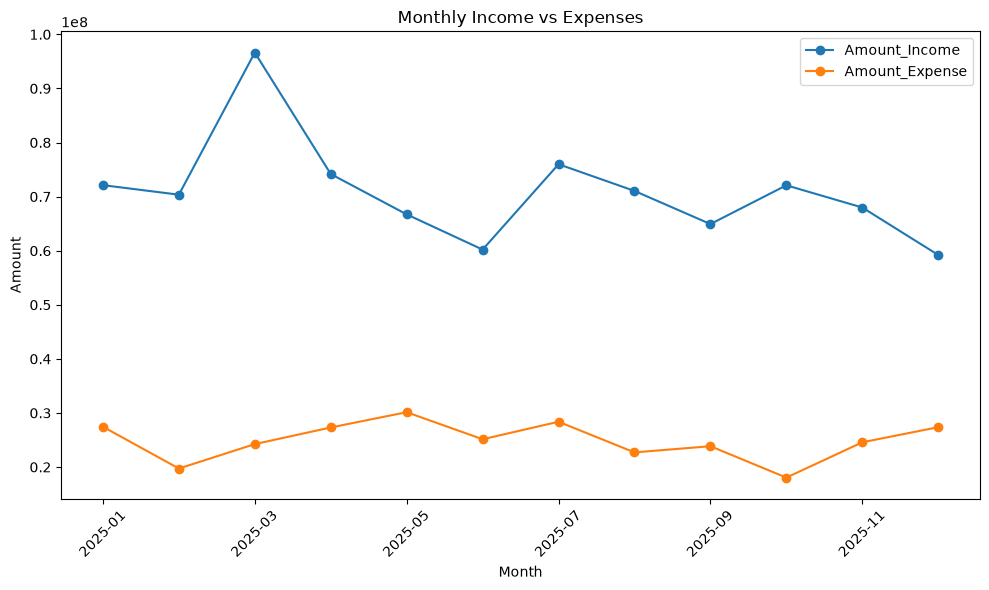

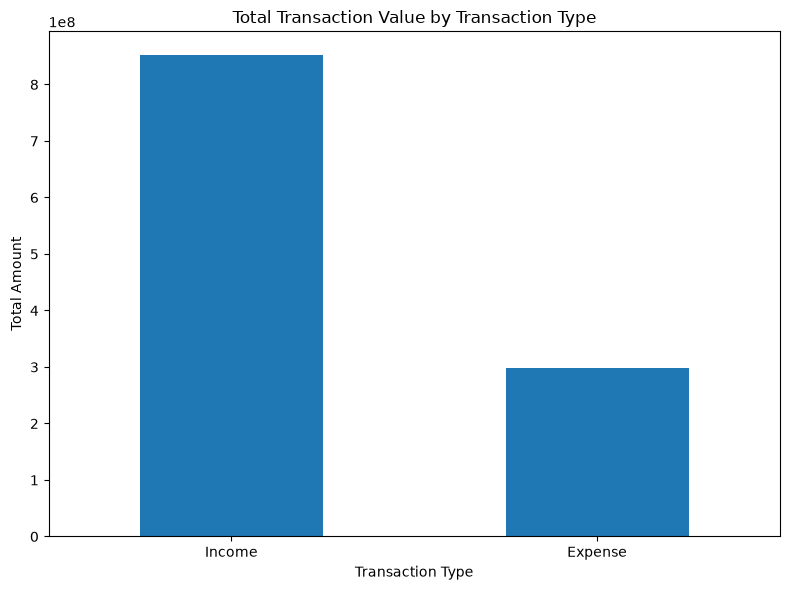

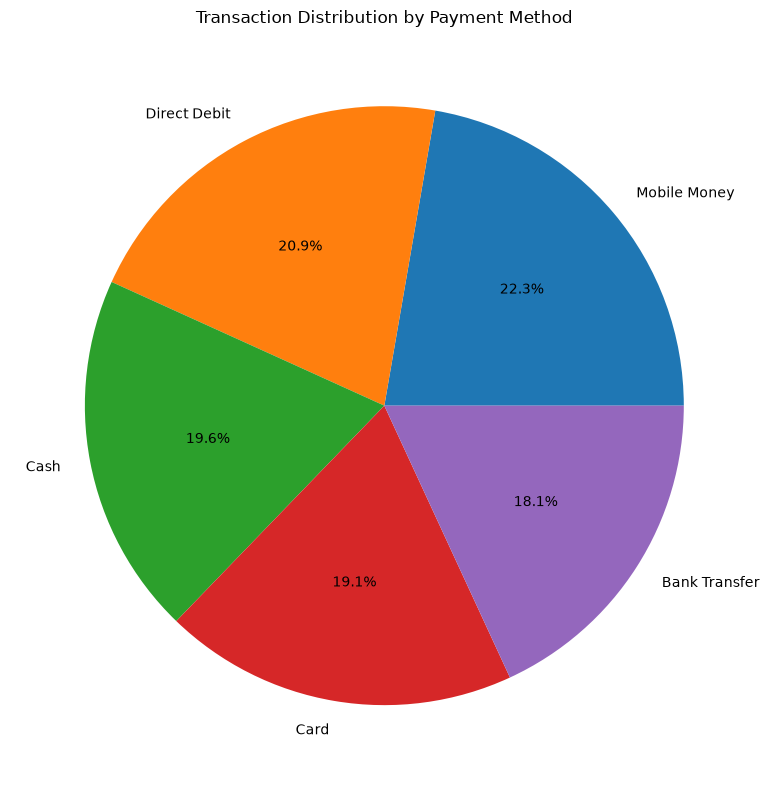

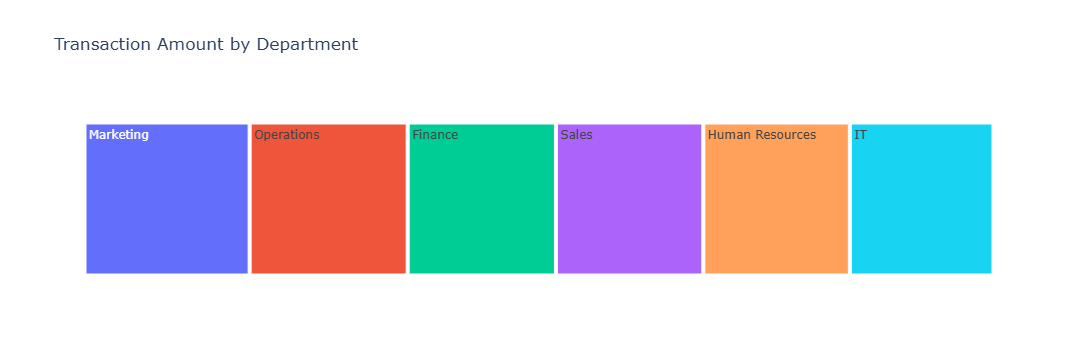


FINANCIAL AUTOMATION PIPELINE COMPLETED SUCCESSFULLY

Output folder: Financial_Automation_Output
Excel workbook: Financial_Automation_Output\Financial_Automation_Output.xlsx

Generated analysis files:
- Enhanced_Monthly_Cash_Flow.csv
- Transaction_Type_Analysis.csv
- Payment_Method_Analysis.csv
- Department_Analysis.csv
- Department_Budget_Analysis.csv
- Large_Transactions_Analysis.csv
- Data_Quality_Summary.csv

Ready for Power BI.


In [78]:
# ============================================================
# FINANCIAL DATA AUTOMATION PIPELINE
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from pathlib import Path


# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv("Clean_Financial_Data.csv")
monthly_report = pd.read_csv("Monthly_Financial_Report.csv")

print("Data loaded successfully.")


# ============================================================
# 2. MONTHLY FINANCIAL ANALYSIS
# ============================================================

# Net Cash Flow
monthly_report["Net_Cash_Flow"] = (
    monthly_report["Amount_Income"] -
    monthly_report["Amount_Expense"]
)

# Cash Flow Margin
monthly_report["Cash_Flow_Margin_%"] = (
    monthly_report["Net_Cash_Flow"] /
    monthly_report["Amount_Income"]
) * 100

# Month-over-Month Income Change
monthly_report["Income_MoM_%"] = (
    monthly_report["Amount_Income"].pct_change()
) * 100

# Month-over-Month Expense Change
monthly_report["Expense_MoM_%"] = (
    monthly_report["Amount_Expense"].pct_change()
) * 100


# ============================================================
# 3. HIGHEST AND LOWEST PERFORMANCE
# ============================================================

highest_income = monthly_report.loc[
    monthly_report["Amount_Income"].idxmax()
]

lowest_income = monthly_report.loc[
    monthly_report["Amount_Income"].idxmin()
]

highest_expense = monthly_report.loc[
    monthly_report["Amount_Expense"].idxmax()
]

lowest_expense = monthly_report.loc[
    monthly_report["Amount_Expense"].idxmin()
]


# ============================================================
# 4. TRANSACTION TYPE ANALYSIS
# ============================================================

transaction_analysis = (
    df.groupby("Transaction_Type")["Amount"]
    .agg(
        Total_Amount="sum",
        Transaction_Count="count",
        Average_Amount="mean"
    )
    .reset_index()
)


# ============================================================
# 5. PAYMENT METHOD ANALYSIS
# ============================================================

payment_analysis = (
    df.groupby("Payment_Method")["Amount"]
    .agg(
        Total_Amount="sum",
        Transaction_Count="count",
        Average_Amount="mean"
    )
    .reset_index()
)


# ============================================================
# 6. DEPARTMENT ANALYSIS
# ============================================================

department_analysis = (
    df.groupby("Department")["Amount"]
    .agg(
        Total_Amount="sum",
        Transaction_Count="count",
        Average_Amount="mean"
    )
    .reset_index()
    .sort_values("Total_Amount", ascending=False)
)


# ============================================================
# 7. DEPARTMENT BUDGET ANALYSIS
# ============================================================

department_budget_analysis = (
    df.groupby("Department")
    .agg(
        Actual_Spending=("Amount", "sum"),
        Transaction_Count=("Amount", "count")
    )
    .reset_index()
)

# Only calculate budget variance if Budget exists
if "Budget" in df.columns:

    budget_summary = (
        df.groupby("Department")["Budget"]
        .sum()
        .reset_index()
    )

    department_budget_analysis = department_budget_analysis.merge(
        budget_summary,
        on="Department",
        how="left"
    )

    department_budget_analysis["Budget_Variance"] = (
        department_budget_analysis["Budget"] -
        department_budget_analysis["Actual_Spending"]
    )

    department_budget_analysis["Budget_Utilisation_%"] = (
        department_budget_analysis["Actual_Spending"] /
        department_budget_analysis["Budget"]
    ) * 100


# ============================================================
# 8. LARGE TRANSACTION ANALYSIS
# ============================================================

transaction_threshold = df["Amount"].quantile(0.95)

large_transactions = df[
    df["Amount"] >= transaction_threshold
].copy()

large_transactions = large_transactions.sort_values(
    "Amount",
    ascending=False
)


# ============================================================
# 9. DATA QUALITY ANALYSIS
# ============================================================

data_quality_summary = pd.DataFrame({
    "Metric": [
        "Total Records",
        "Duplicate Records",
        "Missing Values",
        "Large Transactions",
        "Unique Departments",
        "Unique Payment Methods"
    ],
    "Value": [
        len(df),
        df.duplicated().sum(),
        df.isnull().sum().sum(),
        len(large_transactions),
        df["Department"].nunique(),
        df["Payment_Method"].nunique()
    ]
})


# ============================================================
# 10. VISUALISATION 1
# MONTHLY INCOME VS EXPENSES
# ============================================================

monthly_report.plot(
    x="Month",
    y=["Amount_Income", "Amount_Expense"],
    kind="line",
    marker="o",
    figsize=(10, 6)
)

plt.title("Monthly Income vs Expenses")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ============================================================
# 11. VISUALISATION 2
# TRANSACTION VALUE BY TRANSACTION TYPE
# ============================================================

transaction_type_amount = (
    df.groupby("Transaction_Type")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

transaction_type_amount.plot(
    kind="bar",
    figsize=(8, 6)
)

plt.title("Total Transaction Value by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Total Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ============================================================
# 12. VISUALISATION 3
# PAYMENT METHOD DISTRIBUTION
# ============================================================

payment_method = df["Payment_Method"].value_counts()

payment_method.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(8, 8)
)

plt.title("Transaction Distribution by Payment Method")
plt.ylabel("")
plt.tight_layout()
plt.show()


# ============================================================
# 13. VISUALISATION 4
# DEPARTMENT TRANSACTION TREEMAP
# ============================================================

department_treemap = (
    df.groupby("Department")["Amount"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

fig = px.treemap(
    department_treemap,
    path=["Department"],
    values="Amount",
    title="Transaction Amount by Department"
)

fig.show()


# ============================================================
# 14. CREATE OUTPUT FOLDER
# ============================================================

output_folder = Path("Financial_Automation_Output")
output_folder.mkdir(exist_ok=True)


# ============================================================
# 15. EXPORT AUTOMATED ANALYSIS FILES
# ============================================================

monthly_report.to_csv(
    output_folder / "Enhanced_Monthly_Cash_Flow.csv",
    index=False
)

transaction_analysis.to_csv(
    output_folder / "Transaction_Type_Analysis.csv",
    index=False
)

payment_analysis.to_csv(
    output_folder / "Payment_Method_Analysis.csv",
    index=False
)

department_analysis.to_csv(
    output_folder / "Department_Analysis.csv",
    index=False
)

department_budget_analysis.to_csv(
    output_folder / "Department_Budget_Analysis.csv",
    index=False
)

large_transactions.to_csv(
    output_folder / "Large_Transactions_Analysis.csv",
    index=False
)

data_quality_summary.to_csv(
    output_folder / "Data_Quality_Summary.csv",
    index=False
)


# ============================================================
# 16. EXPORT EXCEL WORKBOOK FOR POWER BI
# ============================================================

excel_path = output_folder / "Financial_Automation_Output.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:

    df.to_excel(
        writer,
        sheet_name="Clean_Data",
        index=False
    )

    monthly_report.to_excel(
        writer,
        sheet_name="Monthly_Cash_Flow",
        index=False
    )

    transaction_analysis.to_excel(
        writer,
        sheet_name="Transaction_Type",
        index=False
    )

    payment_analysis.to_excel(
        writer,
        sheet_name="Payment_Method",
        index=False
    )

    department_analysis.to_excel(
        writer,
        sheet_name="Department",
        index=False
    )

    department_budget_analysis.to_excel(
        writer,
        sheet_name="Department_Budget",
        index=False
    )

    large_transactions.to_excel(
        writer,
        sheet_name="Large_Transactions",
        index=False
    )

    data_quality_summary.to_excel(
        writer,
        sheet_name="Data_Quality",
        index=False
    )


# ============================================================
# 17. FINAL STATUS
# ============================================================

print("\n" + "=" * 60)
print("FINANCIAL AUTOMATION PIPELINE COMPLETED SUCCESSFULLY")
print("=" * 60)

print(f"\nOutput folder: {output_folder}")
print(f"Excel workbook: {excel_path}")

print("\nGenerated analysis files:")
print("- Enhanced_Monthly_Cash_Flow.csv")
print("- Transaction_Type_Analysis.csv")
print("- Payment_Method_Analysis.csv")
print("- Department_Analysis.csv")
print("- Department_Budget_Analysis.csv")
print("- Large_Transactions_Analysis.csv")
print("- Data_Quality_Summary.csv")

print("\nReady for Power BI.")

In [79]:
import pandas as pd

monthly_report = pd.read_csv("Monthly_Financial_Report.csv")

monthly_report.head()

,Month,Amount_Income,Amount_Expense
0,2025-01,72118202.0,27445428.0
1,2025-02,70357945.0,19723373.0
2,2025-03,96634778.0,24235590.0
3,2025-04,74179658.0,27310979.0
4,2025-05,66718405.0,30138743.0


In [80]:
monthly_report.shape

(12, 3)

In [81]:
monthly_report.tail()

,Month,Amount_Income,Amount_Expense
7,2025-08,71052379.0,22703883.0
8,2025-09,64926239.0,23846026.0
9,2025-10,72093872.0,18044338.0
10,2025-11,67987258.0,24573140.0
11,2025-12,59209129.0,27364930.0


In [82]:
monthly_report

,Month,Amount_Income,Amount_Expense
0,2025-01,72118202.0,27445428.0
1,2025-02,70357945.0,19723373.0
2,2025-03,96634778.0,24235590.0
3,2025-04,74179658.0,27310979.0
4,2025-05,66718405.0,30138743.0
5,2025-06,60204675.0,25132497.0
6,2025-07,75990871.0,28372544.0
7,2025-08,71052379.0,22703883.0
8,2025-09,64926239.0,23846026.0
9,2025-10,72093872.0,18044338.0


In [83]:
monthly_report.dtypes

Month                 str
Amount_Income     float64
Amount_Expense    float64
dtype: object

In [84]:
# ============================================================
# PREDICTIVE ANALYSIS - DATA PREPARATION
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Convert Month to datetime
monthly_report["Month"] = pd.to_datetime(
    monthly_report["Month"]
)

# Sort by month
monthly_report = monthly_report.sort_values(
    "Month"
).reset_index(drop=True)

# Calculate Net Cash Flow
monthly_report["Net_Cash_Flow"] = (
    monthly_report["Amount_Income"]
    - monthly_report["Amount_Expense"]
)

# Display the prepared data
monthly_report

,Month,Amount_Income,Amount_Expense,Net_Cash_Flow
0,2025-01-01,72118202.0,27445428.0,44672774.0
1,2025-02-01,70357945.0,19723373.0,50634572.0
2,2025-03-01,96634778.0,24235590.0,72399188.0
3,2025-04-01,74179658.0,27310979.0,46868679.0
4,2025-05-01,66718405.0,30138743.0,36579662.0
5,2025-06-01,60204675.0,25132497.0,35072178.0
6,2025-07-01,75990871.0,28372544.0,47618327.0
7,2025-08-01,71052379.0,22703883.0,48348496.0
8,2025-09-01,64926239.0,23846026.0,41080213.0
9,2025-10-01,72093872.0,18044338.0,54049534.0


In [85]:
# ============================================================
# PREDICTIVE ANALYSIS - 3 MONTH FORECAST
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create month numbers
monthly_report["Month_Number"] = np.arange(
    1, len(monthly_report) + 1
)

# Create future month numbers
future_months = np.arange(
    len(monthly_report) + 1,
    len(monthly_report) + 4
)

# Future dates
future_dates = pd.date_range(
    start=monthly_report["Month"].max()
    + pd.DateOffset(months=1),
    periods=3,
    freq="MS"
)

# ------------------------------------------------------------
# Forecast Income
# ------------------------------------------------------------
income_model = np.polyfit(
    monthly_report["Month_Number"],
    monthly_report["Amount_Income"],
    1
)

income_forecast = np.polyval(
    income_model,
    future_months
)

# ------------------------------------------------------------
# Forecast Expenses
# ------------------------------------------------------------
expense_model = np.polyfit(
    monthly_report["Month_Number"],
    monthly_report["Amount_Expense"],
    1
)

expense_forecast = np.polyval(
    expense_model,
    future_months
)

# ------------------------------------------------------------
# Create Forecast Table
# ------------------------------------------------------------
forecast = pd.DataFrame({
    "Month": future_dates,
    "Forecast_Income": income_forecast,
    "Forecast_Expense": expense_forecast
})

# Calculate forecast Net Cash Flow
forecast["Forecast_Net_Cash_Flow"] = (
    forecast["Forecast_Income"]
    - forecast["Forecast_Expense"]
)

# Display forecast
forecast

,Month,Forecast_Income,Forecast_Expense,Forecast_Net_Cash_Flow
0,2026-01-01,6.294245e+07,2.406749e+07,3.887496e+07
1,2026-02-01,6.170958e+07,2.393824e+07,3.777134e+07
2,2026-03-01,6.047671e+07,2.380899e+07,3.666771e+07


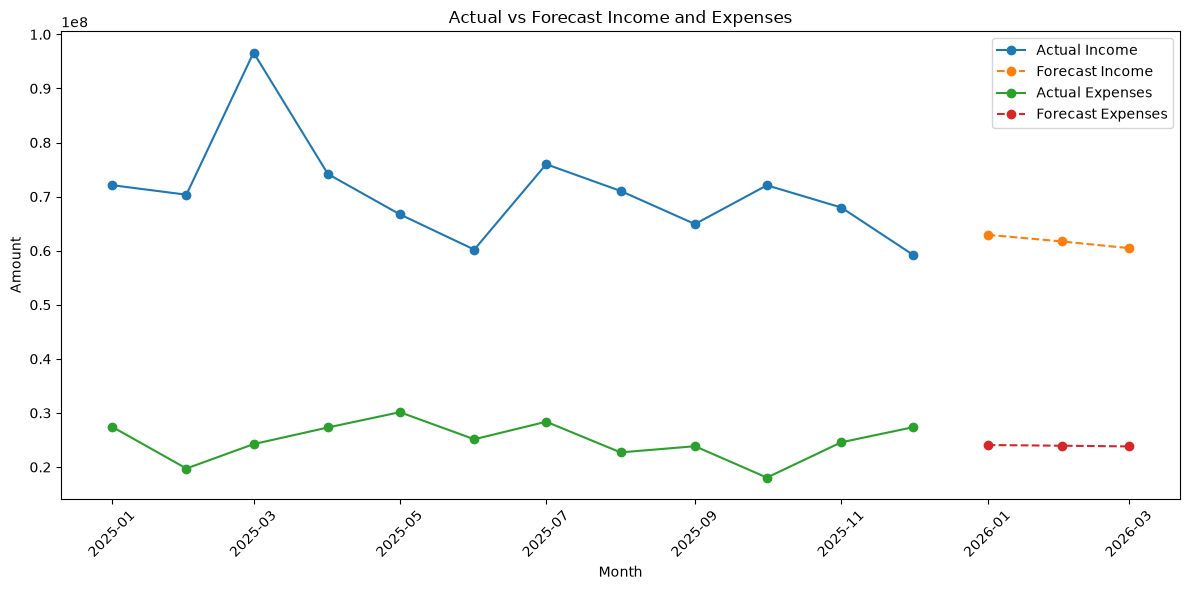

In [86]:
# ============================================================
# ACTUAL VS FORECAST VISUALISATION
# ============================================================

plt.figure(figsize=(12, 6))

# Actual Income
plt.plot(
    monthly_report["Month"],
    monthly_report["Amount_Income"],
    marker="o",
    label="Actual Income"
)

# Forecast Income
plt.plot(
    forecast["Month"],
    forecast["Forecast_Income"],
    marker="o",
    linestyle="--",
    label="Forecast Income"
)

# Actual Expenses
plt.plot(
    monthly_report["Month"],
    monthly_report["Amount_Expense"],
    marker="o",
    label="Actual Expenses"
)

# Forecast Expenses
plt.plot(
    forecast["Month"],
    forecast["Forecast_Expense"],
    marker="o",
    linestyle="--",
    label="Forecast Expenses"
)

plt.title("Actual vs Forecast Income and Expenses")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

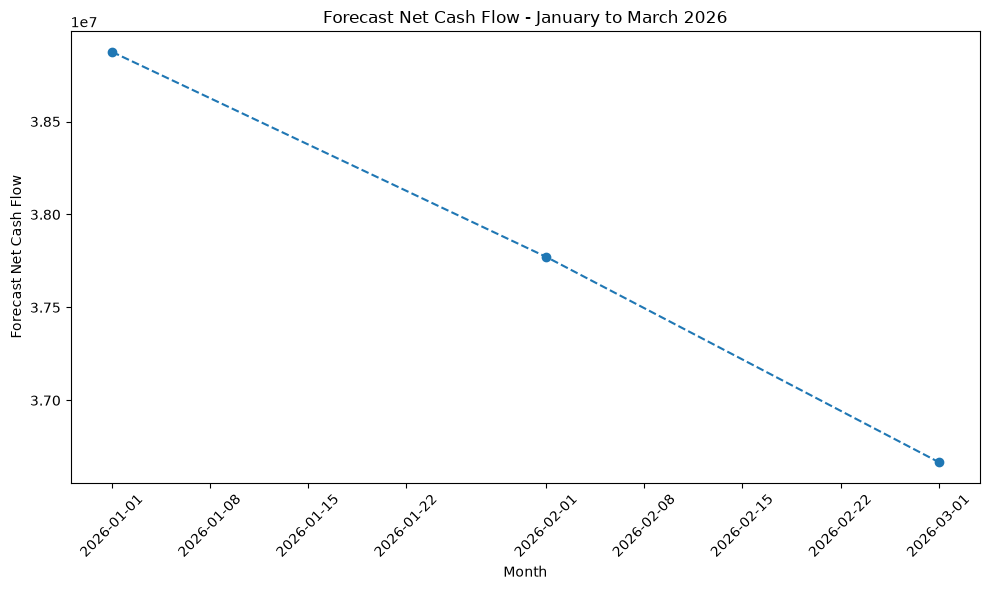

In [87]:
# ============================================================
# FORECAST NET CASH FLOW
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    forecast["Month"],
    forecast["Forecast_Net_Cash_Flow"],
    marker="o",
    linestyle="--"
)

plt.title("Forecast Net Cash Flow - January to March 2026")
plt.xlabel("Month")
plt.ylabel("Forecast Net Cash Flow")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [88]:
# ============================================================
# EXPORT FORECAST RESULTS
# ============================================================

from pathlib import Path

# Create output folder
output_folder = Path("Financial_Automation_Output")
output_folder.mkdir(exist_ok=True)

# Define Excel workbook path
excel_path = output_folder / "Financial_Automation_Output.xlsx"

# Save forecast as CSV
forecast.to_csv(
    output_folder / "Financial_Forecast.csv",
    index=False
)

# Add forecast to Excel workbook
with pd.ExcelWriter(
    excel_path,
    engine="openpyxl",
    mode="a" if excel_path.exists() else "w",
    if_sheet_exists="replace" if excel_path.exists() else None
) as writer:

    forecast.to_excel(
        writer,
        sheet_name="Financial_Forecast",
        index=False
    )

print("Forecast exported successfully!")
print(f"CSV file: {output_folder / 'Financial_Forecast.csv'}")
print(f"Excel workbook: {excel_path}")

Forecast exported successfully!
CSV file: Financial_Automation_Output\Financial_Forecast.csv
Excel workbook: Financial_Automation_Output\Financial_Automation_Output.xlsx


Data loaded successfully.


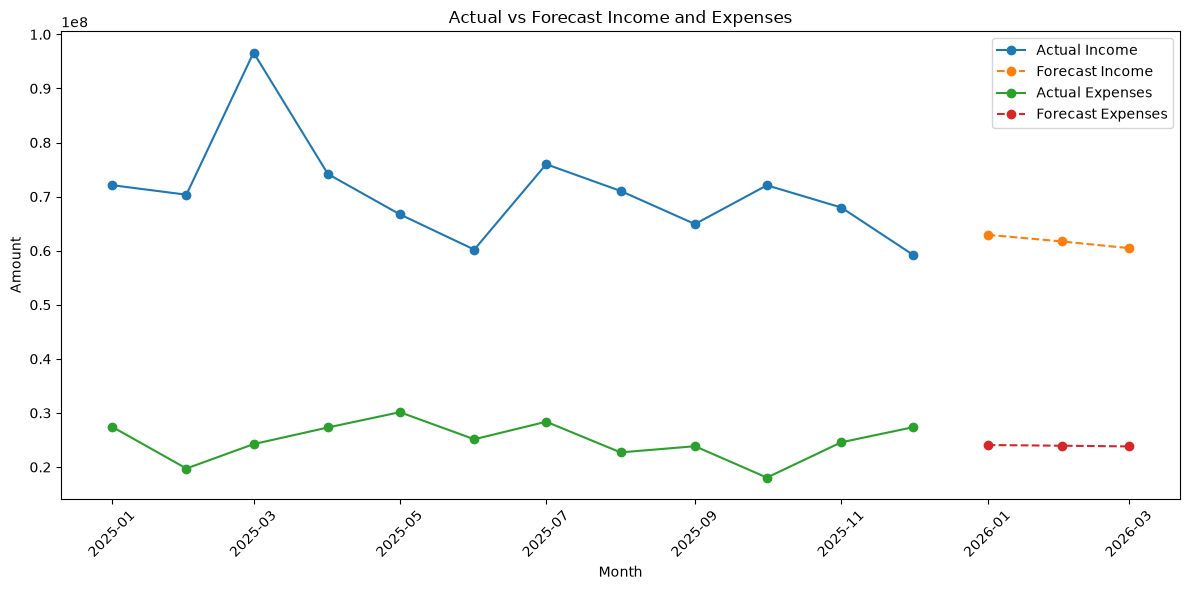

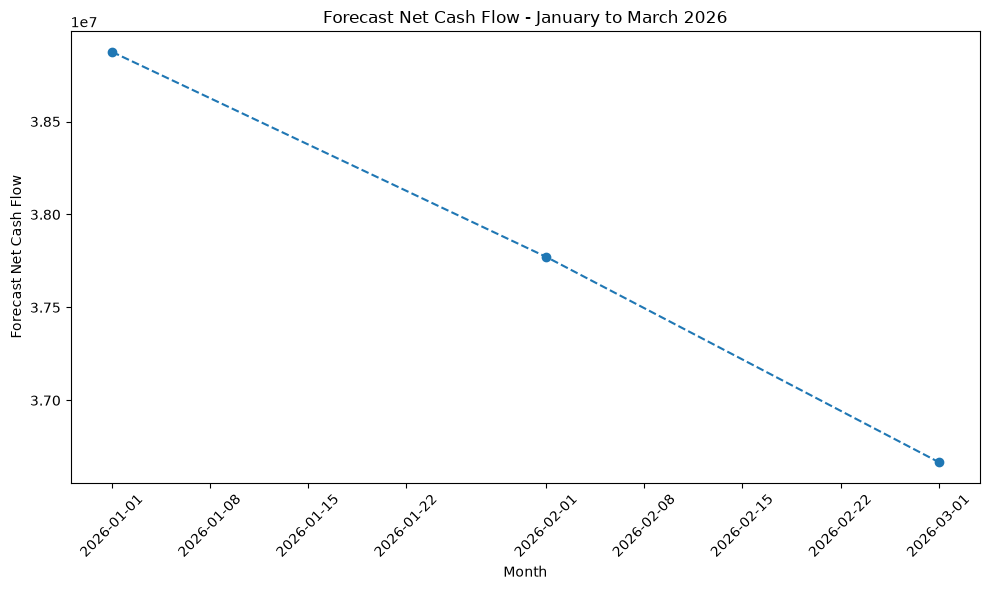


COMPLETE FINANCIAL AUTOMATION PIPELINE
COMPLETED SUCCESSFULLY

Pipeline:
Load → Transform → Analyse → Forecast → Visualise → Export

Forecast:
January 2026
February 2026
March 2026

Output folder:
Financial_Automation_Output

Excel workbook:
Financial_Automation_Output\Financial_Automation_Output.xlsx

All outputs are ready for Power BI.


In [89]:
# ============================================================
# COMPLETE FINANCIAL DATA AUTOMATION PIPELINE
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from pathlib import Path


# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv("Clean_Financial_Data.csv")
monthly_report = pd.read_csv("Monthly_Financial_Report.csv")

print("Data loaded successfully.")


# ============================================================
# 2. PREPARE MONTHLY DATA
# ============================================================

monthly_report["Month"] = pd.to_datetime(
    monthly_report["Month"]
)

monthly_report = monthly_report.sort_values(
    "Month"
).reset_index(drop=True)


# ============================================================
# 3. MONTHLY FINANCIAL ANALYSIS
# ============================================================

monthly_report["Net_Cash_Flow"] = (
    monthly_report["Amount_Income"]
    - monthly_report["Amount_Expense"]
)

monthly_report["Cash_Flow_Margin_%"] = (
    monthly_report["Net_Cash_Flow"]
    / monthly_report["Amount_Income"]
) * 100

monthly_report["Income_MoM_%"] = (
    monthly_report["Amount_Income"].pct_change()
) * 100

monthly_report["Expense_MoM_%"] = (
    monthly_report["Amount_Expense"].pct_change()
) * 100


# ============================================================
# 4. HIGHEST AND LOWEST PERFORMANCE
# ============================================================

highest_income = monthly_report.loc[
    monthly_report["Amount_Income"].idxmax()
]

lowest_income = monthly_report.loc[
    monthly_report["Amount_Income"].idxmin()
]

highest_expense = monthly_report.loc[
    monthly_report["Amount_Expense"].idxmax()
]

lowest_expense = monthly_report.loc[
    monthly_report["Amount_Expense"].idxmin()
]


# ============================================================
# 5. TRANSACTION TYPE ANALYSIS
# ============================================================

transaction_analysis = (
    df.groupby("Transaction_Type")["Amount"]
    .agg(
        Total_Amount="sum",
        Transaction_Count="count",
        Average_Amount="mean"
    )
    .reset_index()
)


# ============================================================
# 6. PAYMENT METHOD ANALYSIS
# ============================================================

payment_analysis = (
    df.groupby("Payment_Method")["Amount"]
    .agg(
        Total_Amount="sum",
        Transaction_Count="count",
        Average_Amount="mean"
    )
    .reset_index()
)


# ============================================================
# 7. DEPARTMENT ANALYSIS
# ============================================================

department_analysis = (
    df.groupby("Department")["Amount"]
    .agg(
        Total_Amount="sum",
        Transaction_Count="count",
        Average_Amount="mean"
    )
    .reset_index()
    .sort_values(
        "Total_Amount",
        ascending=False
    )
)


# ============================================================
# 8. DEPARTMENT BUDGET ANALYSIS
# ============================================================

department_budget_analysis = (
    df.groupby("Department")
    .agg(
        Actual_Spending=("Amount", "sum"),
        Transaction_Count=("Amount", "count")
    )
    .reset_index()
)

if "Budget" in df.columns:

    budget_summary = (
        df.groupby("Department")["Budget"]
        .sum()
        .reset_index()
    )

    department_budget_analysis = (
        department_budget_analysis.merge(
            budget_summary,
            on="Department",
            how="left"
        )
    )

    department_budget_analysis["Budget_Variance"] = (
        department_budget_analysis["Budget"]
        - department_budget_analysis["Actual_Spending"]
    )

    department_budget_analysis["Budget_Utilisation_%"] = (
        department_budget_analysis["Actual_Spending"]
        / department_budget_analysis["Budget"]
    ) * 100


# ============================================================
# 9. LARGE TRANSACTION ANALYSIS
# ============================================================

transaction_threshold = df["Amount"].quantile(0.95)

large_transactions = df[
    df["Amount"] >= transaction_threshold
].copy()

large_transactions = large_transactions.sort_values(
    "Amount",
    ascending=False
)


# ============================================================
# 10. DATA QUALITY ANALYSIS
# ============================================================

data_quality_summary = pd.DataFrame({

    "Metric": [
        "Total Records",
        "Duplicate Records",
        "Missing Values",
        "Large Transactions",
        "Unique Departments",
        "Unique Payment Methods"
    ],

    "Value": [
        len(df),
        df.duplicated().sum(),
        df.isnull().sum().sum(),
        len(large_transactions),
        df["Department"].nunique(),
        df["Payment_Method"].nunique()
    ]
})


# ============================================================
# 11. PREDICTIVE ANALYSIS
# 3-MONTH FORECAST
# ============================================================

monthly_report["Month_Number"] = np.arange(
    1,
    len(monthly_report) + 1
)

future_months = np.arange(
    len(monthly_report) + 1,
    len(monthly_report) + 4
)

future_dates = pd.date_range(
    start=monthly_report["Month"].max()
    + pd.DateOffset(months=1),
    periods=3,
    freq="MS"
)


# Forecast Income
income_model = np.polyfit(
    monthly_report["Month_Number"],
    monthly_report["Amount_Income"],
    1
)

income_forecast = np.polyval(
    income_model,
    future_months
)


# Forecast Expenses
expense_model = np.polyfit(
    monthly_report["Month_Number"],
    monthly_report["Amount_Expense"],
    1
)

expense_forecast = np.polyval(
    expense_model,
    future_months
)


# Create forecast table
forecast = pd.DataFrame({

    "Month": future_dates,

    "Forecast_Income": income_forecast,

    "Forecast_Expense": expense_forecast

})


forecast["Forecast_Net_Cash_Flow"] = (
    forecast["Forecast_Income"]
    - forecast["Forecast_Expense"]
)


# ============================================================
# 12. VISUALISATION - ACTUAL VS FORECAST
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_report["Month"],
    monthly_report["Amount_Income"],
    marker="o",
    label="Actual Income"
)

plt.plot(
    forecast["Month"],
    forecast["Forecast_Income"],
    marker="o",
    linestyle="--",
    label="Forecast Income"
)

plt.plot(
    monthly_report["Month"],
    monthly_report["Amount_Expense"],
    marker="o",
    label="Actual Expenses"
)

plt.plot(
    forecast["Month"],
    forecast["Forecast_Expense"],
    marker="o",
    linestyle="--",
    label="Forecast Expenses"
)

plt.title("Actual vs Forecast Income and Expenses")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 13. VISUALISATION - FORECAST NET CASH FLOW
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    forecast["Month"],
    forecast["Forecast_Net_Cash_Flow"],
    marker="o",
    linestyle="--"
)

plt.title(
    "Forecast Net Cash Flow - January to March 2026"
)

plt.xlabel("Month")
plt.ylabel("Forecast Net Cash Flow")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# ============================================================
# 14. CREATE OUTPUT FOLDER
# ============================================================

output_folder = Path(
    "Financial_Automation_Output"
)

output_folder.mkdir(
    exist_ok=True
)


# ============================================================
# 15. EXPORT CSV FILES
# ============================================================

monthly_report.to_csv(
    output_folder / "Enhanced_Monthly_Cash_Flow.csv",
    index=False
)

transaction_analysis.to_csv(
    output_folder / "Transaction_Type_Analysis.csv",
    index=False
)

payment_analysis.to_csv(
    output_folder / "Payment_Method_Analysis.csv",
    index=False
)

department_analysis.to_csv(
    output_folder / "Department_Analysis.csv",
    index=False
)

department_budget_analysis.to_csv(
    output_folder / "Department_Budget_Analysis.csv",
    index=False
)

large_transactions.to_csv(
    output_folder / "Large_Transactions_Analysis.csv",
    index=False
)

data_quality_summary.to_csv(
    output_folder / "Data_Quality_Summary.csv",
    index=False
)

forecast.to_csv(
    output_folder / "Financial_Forecast.csv",
    index=False
)


# ============================================================
# 16. EXPORT POWER BI EXCEL WORKBOOK
# ============================================================

excel_path = (
    output_folder /
    "Financial_Automation_Output.xlsx"
)

with pd.ExcelWriter(
    excel_path,
    engine="openpyxl"
) as writer:

    df.to_excel(
        writer,
        sheet_name="Clean_Data",
        index=False
    )

    monthly_report.to_excel(
        writer,
        sheet_name="Monthly_Cash_Flow",
        index=False
    )

    transaction_analysis.to_excel(
        writer,
        sheet_name="Transaction_Type",
        index=False
    )

    payment_analysis.to_excel(
        writer,
        sheet_name="Payment_Method",
        index=False
    )

    department_analysis.to_excel(
        writer,
        sheet_name="Department",
        index=False
    )

    department_budget_analysis.to_excel(
        writer,
        sheet_name="Department_Budget",
        index=False
    )

    large_transactions.to_excel(
        writer,
        sheet_name="Large_Transactions",
        index=False
    )

    data_quality_summary.to_excel(
        writer,
        sheet_name="Data_Quality",
        index=False
    )

    forecast.to_excel(
        writer,
        sheet_name="Financial_Forecast",
        index=False
    )


# ============================================================
# 17. FINAL STATUS
# ============================================================

print("\n" + "=" * 60)
print("COMPLETE FINANCIAL AUTOMATION PIPELINE")
print("COMPLETED SUCCESSFULLY")
print("=" * 60)

print("\nPipeline:")
print("Load → Transform → Analyse → Forecast → Visualise → Export")

print("\nForecast:")
print("January 2026")
print("February 2026")
print("March 2026")

print("\nOutput folder:")
print(output_folder)

print("\nExcel workbook:")
print(excel_path)

print("\nAll outputs are ready for Power BI.")